In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q monai nibabel tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 44.8 MB/s eta 0:00:00


In [ ]:
import torch
import numpy as np
import nibabel as nib
import os
from torch.utils.data import Dataset, DataLoader
from monai.networks.nets import UNet
import matplotlib.pyplot as plt

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


In [ ]:
root_path = "/content/drive/MyDrive/brain segmentation/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData"

patients = sorted(os.listdir(root_path))[:500]

class BraTSDataset(Dataset):
    def __init__(self, root_path, patient_list):
        self.root_path = root_path
        self.patient_list = patient_list

    def __len__(self):
        return len(self.patient_list)

    def normalize(self, x):
        return (x - np.mean(x)) / (np.std(x) + 1e-5)

    def center_crop(self, x, size=64):  # SMALLER = SAFE
        z, y, x_dim = x.shape
        z1 = (z - size)//2
        y1 = (y - size)//2
        x1 = (x_dim - size)//2
        return x[z1:z1+size, y1:y1+size, x1:x1+size]

    def __getitem__(self, idx):
        patient = self.patient_list[idx]
        patient_path = os.path.join(self.root_path, patient)

        try:
            t1  = nib.load(os.path.join(patient_path, f"{patient}-t1n.nii.gz")).get_fdata()
            t1c = nib.load(os.path.join(patient_path, f"{patient}-t1c.nii.gz")).get_fdata()
            t2f = nib.load(os.path.join(patient_path, f"{patient}-t2f.nii.gz")).get_fdata()
            t2w = nib.load(os.path.join(patient_path, f"{patient}-t2w.nii.gz")).get_fdata()
            seg = nib.load(os.path.join(patient_path, f"{patient}-seg.nii.gz")).get_fdata()
        except:
            return self.__getitem__((idx + 1) % len(self.patient_list))

        t1  = self.center_crop(self.normalize(t1))
        t1c = self.center_crop(self.normalize(t1c))
        t2f = self.center_crop(self.normalize(t2f))
        t2w = self.center_crop(self.normalize(t2w))
        seg = self.center_crop(seg)

        volume = np.stack([t1, t1c, t2f, t2w], axis=0)

        return (
            torch.tensor(volume, dtype=torch.float32),
            torch.tensor(seg, dtype=torch.long)
        )

In [ ]:
val_patients = patients[int(0.8 * len(patients)):]  # last 20%

val_dataset = BraTSDataset(root_path, val_patients)
val_loader = DataLoader(val_dataset, batch_size=1)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet(
    spatial_dims=3,
    in_channels=4,
    out_channels=4,
    channels=(32, 64, 128, 256),
    strides=(2, 2, 2),
).to(device)

model.load_state_dict(torch.load("/content/drive/MyDrive/best_model.pth"))
model.eval()

print("✅ Model loaded")

✅ Model loaded


In [ ]:
torch.cuda.empty_cache()

num_classes = 4

conf_matrix = torch.zeros((num_classes, num_classes), dtype=torch.int64).to(device)

correct = 0
total = 0

with torch.no_grad():
    for volume, mask in val_loader:
        volume = volume.to(device)
        mask = mask.to(device)

        outputs = model(volume)
        preds = torch.argmax(outputs, dim=1)

        correct += (preds == mask).sum().item()
        total += mask.numel()

        # FAST CONFUSION MATRIX
        mask_flat = mask.view(-1)
        preds_flat = preds.view(-1)

        k = (mask_flat * num_classes + preds_flat).to(torch.int64)
        bincount = torch.bincount(k, minlength=num_classes**2).to(device)
        conf_matrix += bincount.reshape(num_classes, num_classes)

accuracy = correct / total


📊 FINAL RESULTS:
Accuracy : 0.9482134246826172
Precision: 0.9058472000894066
Recall   : 0.5402399505511478
F1 Score : 0.6755063702610778


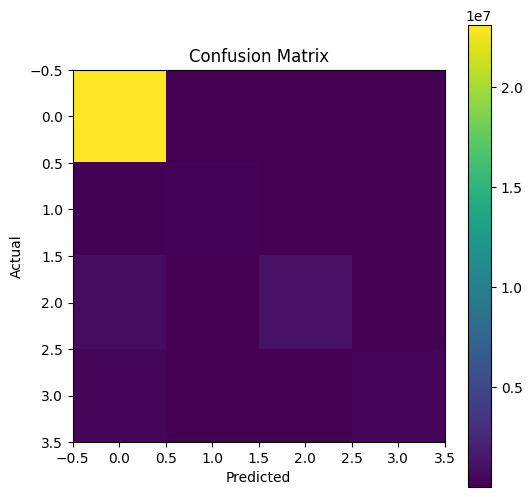

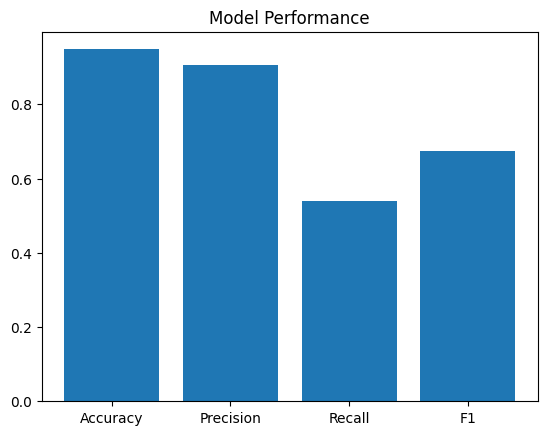

In [ ]:
precision = []
recall = []
f1 = []

for i in range(num_classes):
    TP = conf_matrix[i, i].item()
    FP = conf_matrix[:, i].sum().item() - TP
    FN = conf_matrix[i, :].sum().item() - TP

    p = TP / (TP + FP + 1e-6)
    r = TP / (TP + FN + 1e-6)
    f = 2 * p * r / (p + r + 1e-6)

    precision.append(p)
    recall.append(r)
    f1.append(f)

precision_mean = np.mean(precision[1:])
recall_mean = np.mean(recall[1:])
f1_mean = np.mean(f1[1:])

print("\n📊 FINAL RESULTS:")
print("Accuracy :", accuracy)
print("Precision:", precision_mean)
print("Recall   :", recall_mean)
print("F1 Score :", f1_mean)

# Confusion Matrix
plt.figure(figsize=(6,6))
plt.imshow(conf_matrix.cpu().numpy())
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
# Graph
plt.figure()
plt.bar(["Accuracy","Precision","Recall","F1"],
        [accuracy, precision_mean, recall_mean, f1_mean])
plt.title("Model Performance")
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# -------- YOUR ACTUAL TRAIN LOSS --------
train_losses = [
1.3832, 0.7547, 0.5828, 0.4836, 0.4214, 0.3815, 0.3440, 0.3273,
0.3089, 0.2890, 0.2748, 0.2659, 0.2535, 0.2469, 0.2384, 0.2262,
0.2246, 0.2234, 0.2064, 0.2019, 0.2041, 0.1953, 0.1887, 0.1819,
0.2088, 0.1808, 0.1720, 0.1611, 0.1552, 0.1556, 0.1557, 0.1486,
0.1424, 0.1437, 0.1363, 0.1390, 0.1322, 0.1290, 0.1312, 0.1289,
0.1253, 0.1269
]

# -------- YOUR ACTUAL VAL DICE --------
val_dice_scores = [
0.4411, 0.5398, 0.6026, 0.6274, 0.6888, 0.7039, 0.6817, 0.7046,
0.7367, 0.7492, 0.7498, 0.7515, 0.7604, 0.7485, 0.7431, 0.7639,
0.7409, 0.7723, 0.7673, 0.7646, 0.7511, 0.7653, 0.7762, 0.7724,
0.7730, 0.7874, 0.7861, 0.7945, 0.7833, 0.7935, 0.7894, 0.7948,
0.8049, 0.7929, 0.8041, 0.7953, 0.8020, 0.8050, 0.8091, 0.8078,
0.7847, 0.8000
]

epochs = range(1, len(train_losses)+1)

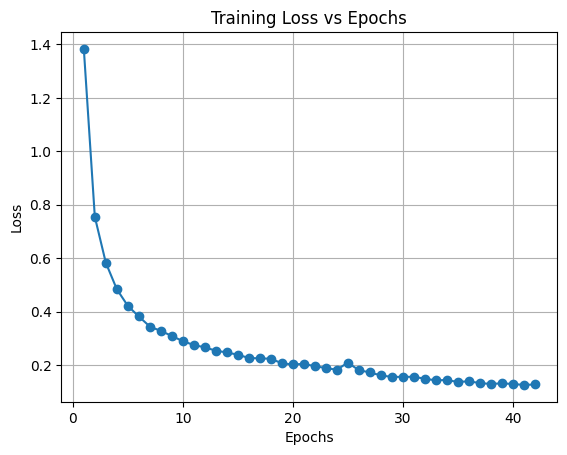

In [ ]:
plt.figure()
plt.plot(epochs, train_losses, marker='o')
plt.title("Training Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid()
plt.show()

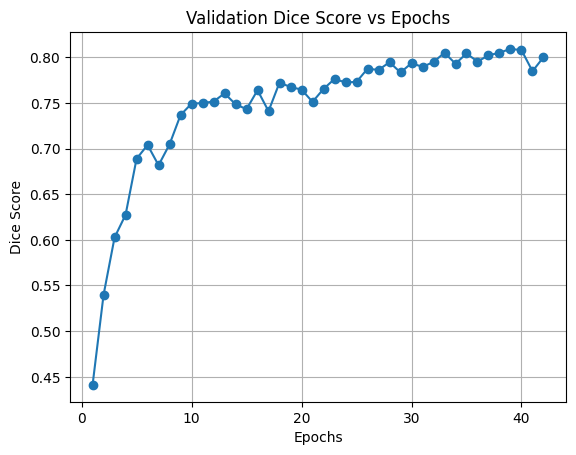

In [ ]:
plt.figure()
plt.plot(epochs, val_dice_scores, marker='o')
plt.title("Validation Dice Score vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Dice Score")
plt.grid()
plt.show()

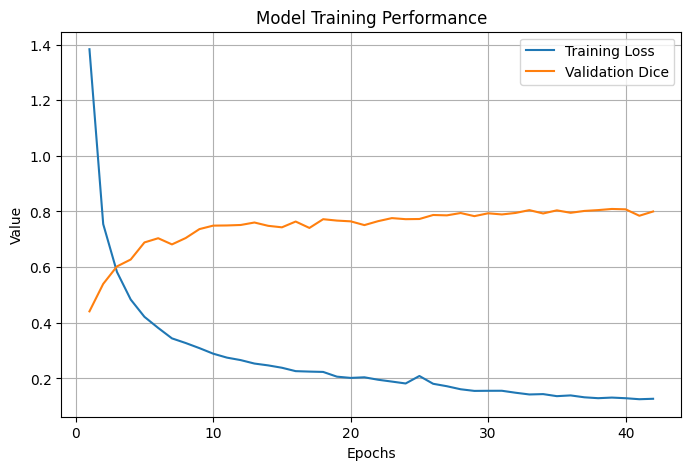

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(epochs, train_losses, label="Training Loss")
plt.plot(epochs, val_dice_scores, label="Validation Dice")

plt.title("Model Training Performance")
plt.xlabel("Epochs")
plt.ylabel("Value")
plt.legend()
plt.grid()

plt.show()
